学习目标
理解欧拉角、四元数的概念

掌握四元数基本运算（乘法、归一化）

能够转换欧拉角和四元数

理论要点
欧拉角：三个角度（滚转φ、俯仰θ、偏航ψ）描述刚体取向。直观但有万向锁问题。

四元数：q = [w, x, y, z]，满足 w² + x² + y² + z² = 1。无奇异性，计算方便。

实践：四元数运算

In [1]:
import numpy as np

def quaternion_multiply(q1, q2):
    """四元数乘法"""
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2
    return np.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ])

def quaternion_conjugate(q):
    """四元数共轭"""
    return np.array([q[0], -q[1], -q[2], -q[3]])

def quaternion_norm(q):
    """四元数模长"""
    return np.sqrt(np.sum(q**2))

def quaternion_normalize(q):
    """归一化"""
    return q / quaternion_norm(q)

# 示例
q1 = np.array([1, 0, 0, 0])  # 单位四元数
q2 = np.array([0, 1, 0, 0])  # 绕X轴180度
q3 = quaternion_multiply(q2, q1)
print("q3:", q3)

# 欧拉角转四元数
def euler_to_quaternion(roll, pitch, yaw):
    cr = np.cos(roll/2)
    sr = np.sin(roll/2)
    cp = np.cos(pitch/2)
    sp = np.sin(pitch/2)
    cy = np.cos(yaw/2)
    sy = np.sin(yaw/2)
    w = cr*cp*cy + sr*sp*sy
    x = sr*cp*cy - cr*sp*sy
    y = cr*sp*cy + sr*cp*sy
    z = cr*cp*sy - sr*sp*cy
    return np.array([w, x, y, z])

# 测试
roll, pitch, yaw = np.radians([30, 15, 45])
q = euler_to_quaternion(roll, pitch, yaw)
print("四元数:", q)
print("模长:", quaternion_norm(q))  # 应该接近1

q3: [0 1 0 0]
四元数: [0.89769257 0.18882373 0.21467987 0.33527034]
模长: 1.0


学习目标
理解转动惯量、角速度、力矩的关系

掌握欧拉动力学方程

能够数值积分更新状态

理论要点
刚体转动动力学方程：I·α + ω × (I·ω) = τ，其中 I 是转动惯量矩阵，α 是角加速度，ω 是角速度，τ 是外力矩。

运动学方程：四元数导数 dq/dt = 0.5 * q ⊗ [0, ω]ᵀ。

实践：单轴动力学简化
对于单轴，方程简化为 I * θ'' = τ。

In [4]:
class SingleAxisSatellite:
    def __init__(self, I=1.0):
        self.I = I          # 转动惯量
        self.theta = 0.0    # 角度 (rad)
        self.omega = 0.0    # 角速度 (rad/s)
    
    def update(self, torque, dt):
        alpha = torque / self.I
        self.omega += alpha * dt
        self.theta += self.omega * dt
        return self.theta, self.omega

实践：三轴动力学（可选扩展）

In [ ]:
import numpy as np
class ThreeAxisSatellite:
    def __init__(self, I=np.diag([1.2, 1.0, 0.8])):
        self.I = I                    # 转动惯量矩阵
        self.q = np.array([1.,0,0,0]) # 四元数
        self.omega = np.zeros(3)      # 角速度
    
    def dynamics(self, torque):
        # 欧拉动力学方程
        I_omega = self.I @ self.omega
        omega_dot = np.linalg.inv(self.I) @ (torque - np.cross(self.omega, I_omega))
        return omega_dot
    
    def kinematics(self):
        # 四元数运动学
        w, x, y, z = self.q
        wx, wy, wz = self.omega
        q_dot = 0.5 * np.array([
            -x*wx - y*wy - z*wz,
             w*wx + y*wz - z*wy,
             w*wy - x*wz + z*wx,
             w*wz + x*wy - y*wx
        ])
        return q_dot
    
    def update(self, torque, dt):
        omega_dot = self.dynamics(torque)
        self.omega += omega_dot * dt
        q_dot = self.kinematics()
        self.q += q_dot * dt
        self.q = self.q / np.linalg.norm(self.q)  # 归一化
        return self.q, self.omega

学习目标
理解比例(P)、积分(I)、微分(D)的作用

能够实现离散PID控制器

通过调参感受参数对响应的影响

理论要点
比例：对当前误差做出反应，Kp越大响应越快，但可能超调。

积分：消除稳态误差，但可能引起振荡。

微分：预测误差变化，阻尼振荡，但放大噪声。

实践：离散PID类

In [3]:
class PIDController:
    def __init__(self, Kp=1.0, Ki=0.1, Kd=0.05, dt=0.01):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.dt = dt
        self.integral = 0.0
        self.prev_error = 0.0
    
    def compute(self, setpoint, measurement):
        error = setpoint - measurement
        self.integral += error * self.dt
        derivative = (error - self.prev_error) / self.dt
        output = self.Kp * error + self.Ki * self.integral + self.Kd * derivative
        self.prev_error = error
        return output

PID调参实验
结合之前的单轴卫星，编写一个仿真函数，测试不同Kp/Ki/Kd的效果，并绘制响应曲线。

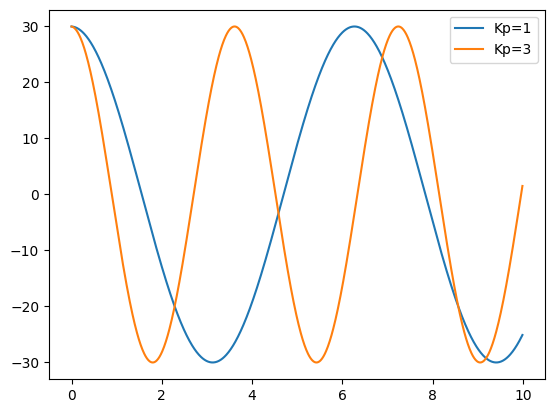

In [5]:
import matplotlib.pyplot as plt
def simulate_pid(Kp, Ki, Kd, initial_angle_deg=30.0, duration=10.0):
    dt = 0.01
    sat = SingleAxisSatellite(I=1.0)
    sat.theta = np.radians(initial_angle_deg)
    pid = PIDController(Kp, Ki, Kd, dt)
    
    time = np.arange(0, duration, dt)
    angles = []
    for t in time:
        torque = pid.compute(0.0, sat.theta)  # 目标角度0
        sat.update(torque, dt)
        angles.append(np.degrees(sat.theta))
    
    return time, angles

# 测试不同Kp
time, angles1 = simulate_pid(Kp=1.0, Ki=0, Kd=0)
time, angles2 = simulate_pid(Kp=3.0, Ki=0, Kd=0)
plt.plot(time, angles1, label='Kp=1')
plt.plot(time, angles2, label='Kp=3')
plt.legend()
plt.show()